# Import Libreries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import mutual_info_regression



# Reading Data

In [2]:
product_detials = pd.read_csv("dataset/PRODUC~1.CSV")
store_info = pd.read_csv("dataset/STORE_~1.CSV")
supplier_info = pd.read_csv("dataset/SUPPLI~1.CSV")
weather_data = pd.read_csv("dataset/WEATHE~1.CSV")
weekly_sales = pd.read_csv("dataset/WEEKLY~1.CSV")

## product details data

In [3]:
product_detials.head()

,Product_ID,Product_Name,Product_Category,Shelf_Life_Days,Supplier_ID
0,1000,Whole Wheat Bread 800g,Bakery,4,4
1,1001,White Sandwich Loaf,Bakery,2,8
2,1002,Croissant 4-pack,Bakery,2,5
3,1003,Blueberry Muffins 6-pack,Bakery,4,10
4,1004,Chocolate Chip Cookies,Bakery,4,7


## Store Info

In [4]:
store_info.head(5)

,Store_ID,Region,Store_Size,Cold_Storage_Capacity
0,500,London,12000,3788
1,501,Midlands,5000,1086
2,502,North East,4000,998
3,503,Midlands,5000,1243
4,504,London,10000,3330


## Supplier Info

In [5]:
supplier_info.head(5)

,Supplier_ID,Supplier_Name,Lead_Time_Days,Supply_Capacity
0,1,FreshFoods UK Ltd.,1,68047
1,2,Quality Provisions Co.,2,35230
2,3,FarmDirect Suppliers Ltd.,2,71976
3,4,PremiumGoods Wholesale,3,48776
4,5,LocalHarvest Distributors,2,11306


## Weather Data

In [6]:
weather_data.head(5)

,Week_Number,Region,Avg_Temperature,Rainfall,Holiday_Flag
0,2024-W01,Midlands,7.4,32.1,0
1,2024-W01,South East,10.5,15.7,0
2,2024-W01,North West,6.8,28.5,1
3,2024-W01,London,9.9,23.0,1
4,2024-W01,South West,10.0,45.9,1


## Weekly Sales

In [7]:
weekly_sales.head(5)

,Week_Number,Product_ID,Store_ID,Units_Sold,Marketing_Spend,Discount_Percent,Wastage_Units,Price
0,2024-W01,1000,500,4853,670.37,0,718,2.46
1,2024-W01,1001,500,4274,1089.62,0,641,1.27
2,2024-W01,1002,500,4215,1004.99,10,632,2.74
3,2024-W01,1003,500,5768,859.45,20,853,1.82
4,2024-W01,1004,500,3403,576.70,0,503,3.46


## Exploratory Data analysis stage 1

In [8]:
def Eda_Stage_1(data, name):
  print("="*100)
  print(f"{name} dataset information")
  print(data.info())
  print("="*100)
  print(f"{name} dataset shape")
  print(data.shape)
  print("="*100)
  print(f"{name} dataset describe")
  print(data.describe())
  print("="*100)
  print(f"{name} dataset columns")
  print(data.columns)
  print("="*100)
  print(f"{name} dataset missing values")
  print(data.isnull().sum())
  print("="*100)
  print(f"{name} dataset duplicate values")
  print(data.duplicated().sum())
  print("="*100)

In [9]:
Eda_Stage_1(product_detials, "product_detials")

product_detials dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product_ID        48 non-null     int64 
 1   Product_Name      48 non-null     object
 2   Product_Category  48 non-null     object
 3   Shelf_Life_Days   48 non-null     int64 
 4   Supplier_ID       48 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 2.0+ KB
None
product_detials dataset shape
(48, 5)
product_detials dataset describe
       Product_ID  Shelf_Life_Days  Supplier_ID
count       48.00        48.000000    48.000000
mean      1023.50        59.916667     5.958333
std         14.00        99.226333     2.782608
min       1000.00         2.000000     1.000000
25%       1011.75         4.000000     4.000000
50%       1023.50         7.500000     6.000000
75%       1035.25        36.250000     8.000000
max       1047.00       356.00

In [10]:
Eda_Stage_1(supplier_info, "supplier_info")

supplier_info dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Supplier_ID      10 non-null     int64 
 1   Supplier_Name    10 non-null     object
 2   Lead_Time_Days   10 non-null     int64 
 3   Supply_Capacity  10 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 448.0+ bytes
None
supplier_info dataset shape
(10, 4)
supplier_info dataset describe
       Supplier_ID  Lead_Time_Days  Supply_Capacity
count     10.00000       10.000000        10.000000
mean       5.50000        2.200000     48161.200000
std        3.02765        0.632456     18121.601841
min        1.00000        1.000000     11306.000000
25%        3.25000        2.000000     38162.250000
50%        5.50000        2.000000     51262.000000
75%        7.75000        2.750000     58185.500000
max       10.00000        3.000000     71976.000000


In [11]:
Eda_Stage_1(weather_data, "weather_data")

weather_data dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Week_Number      364 non-null    object 
 1   Region           364 non-null    object 
 2   Avg_Temperature  364 non-null    float64
 3   Rainfall         364 non-null    float64
 4   Holiday_Flag     364 non-null    int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 14.3+ KB
None
weather_data dataset shape
(364, 5)
weather_data dataset describe
       Avg_Temperature    Rainfall  Holiday_Flag
count       364.000000  364.000000    364.000000
mean         10.015110   20.847253      0.148352
std           6.136098   10.459884      0.355937
min          -2.000000    6.600000      0.000000
25%           4.500000   12.550000      0.000000
50%           9.700000   18.600000      0.000000
75%          15.525000   27.825000      0.000000
max          22

In [12]:
Eda_Stage_1(weekly_sales, "weekly_sales")

weekly_sales dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37440 entries, 0 to 37439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Week_Number       37440 non-null  object 
 1   Product_ID        37440 non-null  int64  
 2   Store_ID          37440 non-null  int64  
 3   Units_Sold        37440 non-null  int64  
 4   Marketing_Spend   37440 non-null  float64
 5   Discount_Percent  37440 non-null  int64  
 6   Wastage_Units     37440 non-null  int64  
 7   Price             37440 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.3+ MB
None
weekly_sales dataset shape
(37440, 8)
weekly_sales dataset describe
         Product_ID      Store_ID    Units_Sold  Marketing_Spend  \
count  37440.000000  37440.000000  37440.000000     37440.000000   
mean    1023.500000    507.000000   1642.154087       410.551195   
std       13.853584      4.320551   1166.477872   

In [13]:
Eda_Stage_1(store_info, "store_info")

store_info dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Store_ID               15 non-null     int64 
 1   Region                 15 non-null     object
 2   Store_Size             15 non-null     int64 
 3   Cold_Storage_Capacity  15 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 608.0+ bytes
None
store_info dataset shape
(15, 4)
store_info dataset describe
         Store_ID    Store_Size  Cold_Storage_Capacity
count   15.000000     15.000000              15.000000
mean   507.000000   5333.333333            1527.066667
std      4.472136   2894.987458             965.651628
min    500.000000   3000.000000             634.000000
25%    503.500000   3500.000000             999.500000
50%    507.000000   4000.000000            1086.000000
75%    510.500000   5000.000000            1509.500000


## EDA Stage 2

In [14]:
print(f"We have the total number of {len(product_detials)} product in the store")
print(f"We have the total number of {len(product_detials['Product_Category'].value_counts())} in the store")

We have the total number of 48 product in the store
We have the total number of 4 in the store


In [15]:
print(f"the sales for 52 weeks is : {len(weekly_sales ):,}")
print(f"the total number of unit sold in {len(weather_data)} days is : {weekly_sales['Units_Sold'].sum():,}")
print(f"the total number of units wasted or expired units in {len(weather_data)} days is : {weekly_sales['Wastage_Units'].sum():,}")
print(f"the average number of unit solds is {weekly_sales['Units_Sold'].mean():.2f}")
print(f"the average number of wasted units is {weekly_sales['Wastage_Units'].mean():.2f}")

the sales for 52 weeks is : 37,440
the total number of unit sold in 364 days is : 61,482,249
the total number of units wasted or expired units in 364 days is : 4,786,490
the average number of unit solds is 1642.15
the average number of wasted units is 127.84


## Regional Store Distribution - Bar Charts

In [16]:
store_info["Region"].value_counts()

Region
South West    4
London        3
Midlands      3
North East    2
North West    2
South East    1
Name: count, dtype: int64

Text(0, 0.5, 'Total Wastage Units')

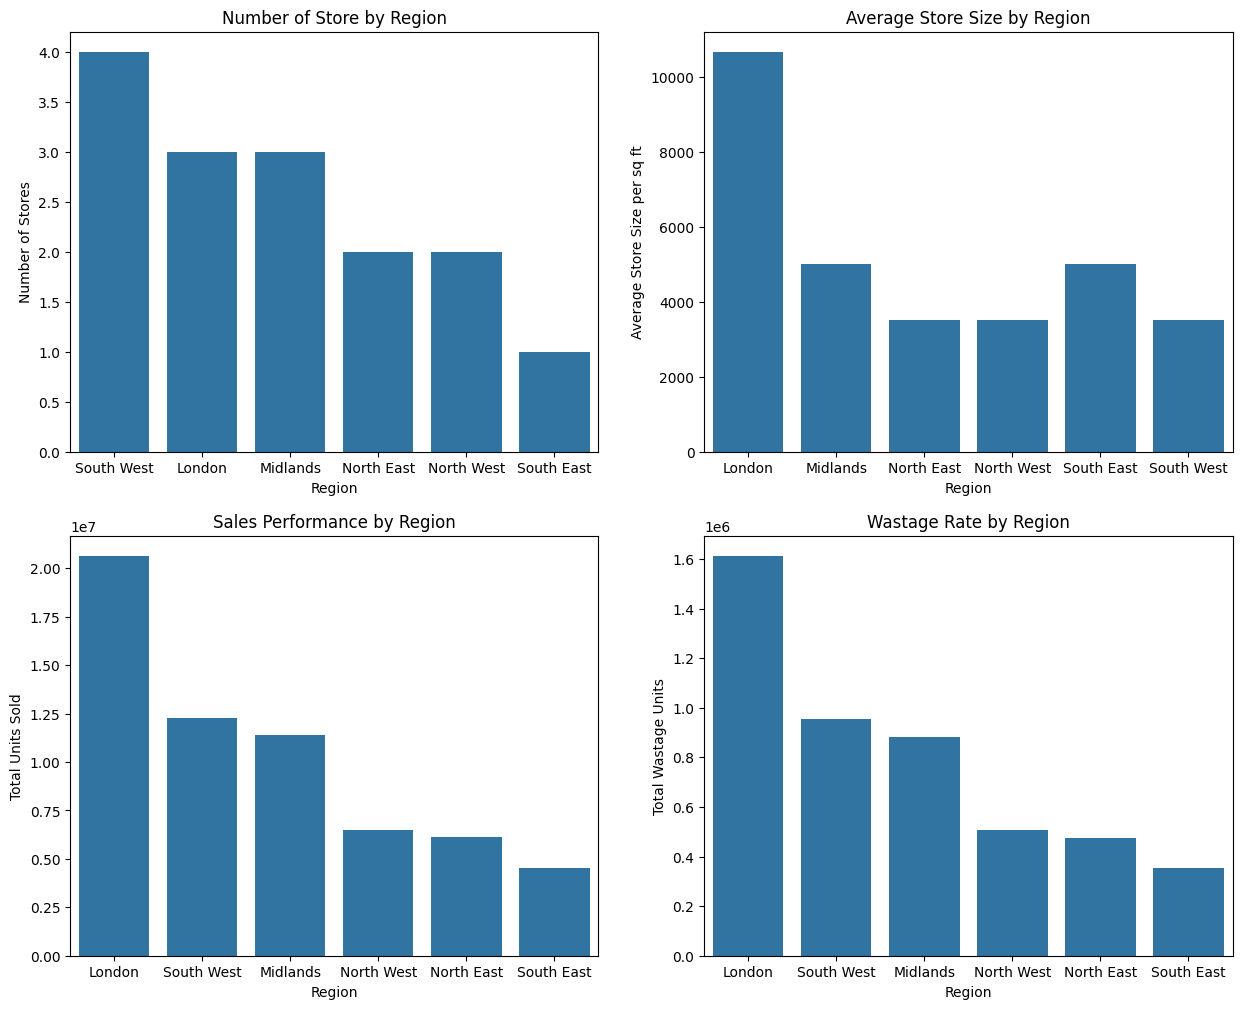

In [17]:
## Sales Performance by region
plt.figure(figsize=(15,12))
plt.subplot(2, 2, 1)
region_store_counts = store_info["Region"].value_counts()
sns.barplot(x=region_store_counts.index, y=region_store_counts.values)
plt.title("Number of Store by Region")
plt.xlabel("Region")
plt.ylabel("Number of Stores")

# average store size per region
plt.subplot(2, 2, 2)
store_size_by_region = store_info.groupby("Region")["Store_Size"].mean()
sns.barplot(x=store_size_by_region.index, y=store_size_by_region.values)
plt.title("Average Store Size by Region")
plt.xlabel("Region")
plt.ylabel("Average Store Size per sq ft")

# sales performance per region
plt.subplot(2, 2, 3)
region_sales = weekly_sales.merge(store_info, on="Store_ID")
store_region_performance = region_sales.groupby("Region")["Units_Sold"].sum().sort_values(ascending=False)
sns.barplot(x=store_region_performance.index, y=store_region_performance.values)
plt.title("Sales Performance by Region")
plt.xlabel("Region")
plt.ylabel("Total Units Sold")
plt

# Wastage rate per region
plt.subplot(2, 2, 4)
Goods_wastage_by_region = region_sales.groupby("Region")["Wastage_Units"].sum().sort_values(ascending=False)
sns.barplot(x=Goods_wastage_by_region.index, y=Goods_wastage_by_region.values)
plt.title("Wastage Rate by Region")
plt.xlabel("Region")
plt.ylabel("Total Wastage Units")

Average price per product across all category
Discount performance

/tmp/ipykernel_504960/1956410167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_per_product_category.index,


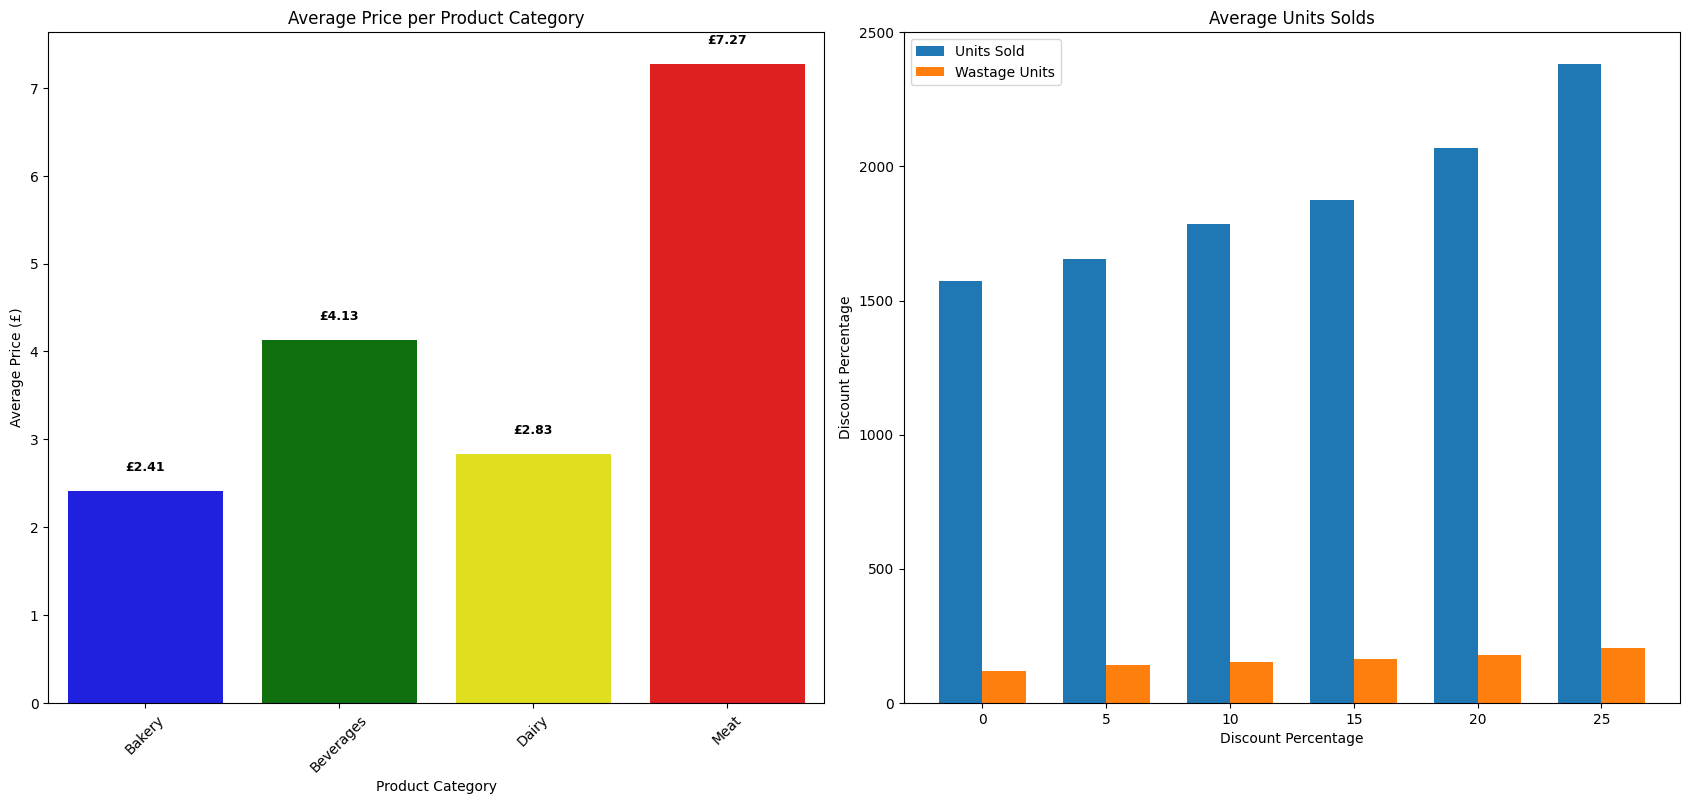

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize =(17, 15))
plt.subplot(2, 2, 1)
# average price per product across all category
category_price = weekly_sales.merge(product_detials, on='Product_ID')
price_per_product_category = category_price.groupby("Product_Category")['Price'].mean()
sns.barplot(x=price_per_product_category.index,
            y=price_per_product_category.values,
            palette=["blue","green", "yellow", "red"])
plt.title("Average Price per Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45)

for i, (cat, val) in enumerate(zip(price_per_product_category.index, price_per_product_category.values)):
    plt.text(i, val + 0.2, f"£{val:.2f}",
             ha= "center", va="bottom", fontweight="bold", fontsize=9)

# discount performance
plt.subplot(2, 2, 2)
discount_performance = weekly_sales.groupby('Discount_Percent').agg({
    'Units_Sold': 'mean',
    'Wastage_Units': 'mean'
}).reset_index()

x = np.arange(len(discount_performance))
width = 0.35

bars1 = plt.bar(x - width/2, discount_performance['Units_Sold'], width, label = 'Units Sold')
bars2 = plt.bar(x + width/2, discount_performance['Wastage_Units'], width, label = 'Wastage Units')

plt.xlabel("Discount Percentage")
plt.ylabel("Discount Percentage")
plt.title("Average Units Solds")
plt.xticks(x, discount_performance['Discount_Percent'])
plt.legend()

plt.tight_layout()

# Sales Performance by Product Category - Comparison Bars

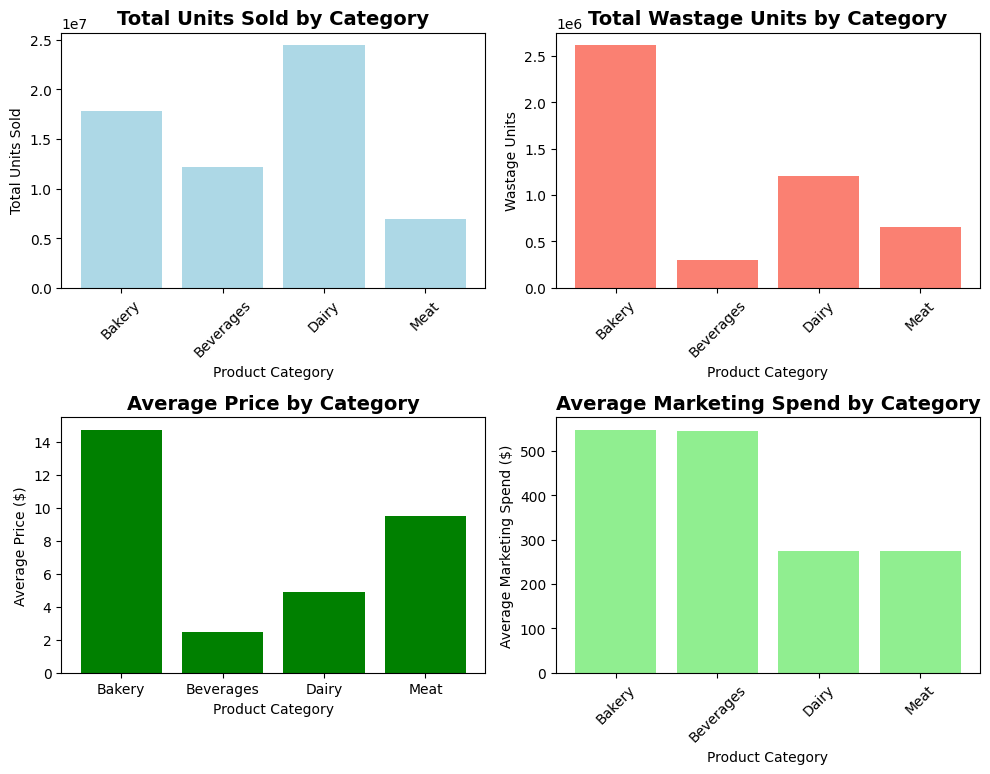

In [19]:
# Sales Performance by Product Category - Comparison Bars
plt.figure(figsize=(10, 8))

# Merge sales with product details
sales_product_details = weekly_sales.merge(product_detials, on='Product_ID')

# Calculate metrics by category
category_metrics = sales_product_details.groupby('Product_Category').agg({
    'Units_Sold': 'sum',
    'Price': 'mean',
    'Wastage_Units': 'sum',
    'Marketing_Spend': 'mean',
}).reset_index()

plt.subplot(2, 2, 1)
plt.bar(category_metrics['Product_Category'], category_metrics['Units_Sold'],color='lightblue')
plt.title('Total Units Sold by Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
category_metrics['Wastage_Rate'] = category_metrics['Wastage_Units'] / category_metrics['Units_Sold'] * 100
plt.bar(category_metrics['Product_Category'], category_metrics['Wastage_Units'],color='salmon')
plt.title('Total Wastage Units by Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Wastage Units')
plt.xticks(rotation=45)

#Wastage rate percentage
#Checking the percentage rate of each product.
plt.subplot(2, 2, 3)
plt.bar(category_metrics['Product_Category'], category_metrics['Wastage_Rate'],color='green')
plt.title('Average Price by Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Average Price ($)')

plt.subplot(2, 2, 4)
plt.bar(category_metrics['Product_Category'], category_metrics['Marketing_Spend'],color='lightgreen')
plt.title('Average Marketing Spend by Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Average Marketing Spend ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
category_metrics

,Product_Category,Units_Sold,Price,Wastage_Units,Marketing_Spend,Wastage_Rate
0,Bakery,17802002,2.412673,2622079,548.040509,14.729124
1,Beverages,12221362,4.132543,300994,545.328623,2.462852
2,Dairy,24514345,2.828795,1204579,274.447224,4.913772
3,Meat,6944540,7.274323,658838,274.388425,9.487137


# Merge Data

In [21]:
print(product_detials.columns)
print(weekly_sales.columns)

Index(['Product_ID', 'Product_Name', 'Product_Category', 'Shelf_Life_Days',
       'Supplier_ID'],
      dtype='object')
Index(['Week_Number', 'Product_ID', 'Store_ID', 'Units_Sold',
       'Marketing_Spend', 'Discount_Percent', 'Wastage_Units', 'Price'],
      dtype='object')


In [22]:
merged_data = pd.merge(product_detials, weekly_sales, on='Product_ID', how = 'inner').merge(store_info, on='Store_ID', how = 'inner').merge( supplier_info, on='Supplier_ID', how = 'inner').merge(weather_data, on=['Week_Number' , 'Region'], how = 'inner')

In [23]:
merged_data

,Product_ID,Product_Name,Product_Category,Shelf_Life_Days,Supplier_ID,Week_Number,Store_ID,Units_Sold,Marketing_Spend,Discount_Percent,...,Price,Region,Store_Size,Cold_Storage_Capacity,Supplier_Name,Lead_Time_Days,Supply_Capacity,Avg_Temperature,Rainfall,Holiday_Flag
0,1000,Whole Wheat Bread 800g,Bakery,4,4,2024-W01,500,4853,670.37,0,...,2.46,London,12000,3788,PremiumGoods Wholesale,3,48776,9.9,23.0,1
1,1006,Cinnamon Rolls 4-pack,Bakery,2,4,2024-W01,500,5562,546.51,0,...,2.27,London,12000,3788,PremiumGoods Wholesale,3,48776,9.9,23.0,1
2,1021,Pork Chops 4-pack,Meat,4,4,2024-W01,500,2199,447.01,0,...,6.52,London,12000,3788,PremiumGoods Wholesale,3,48776,9.9,23.0,1
3,1025,Semi-Skimmed Milk 4-pint,Dairy,8,4,2024-W01,500,7336,183.79,10,...,2.23,London,12000,3788,PremiumGoods Wholesale,3,48776,9.9,23.0,1
4,1031,Mozzarella 250g,Dairy,14,4,2024-W01,500,3766,398.13,0,...,1.35,London,12000,3788,PremiumGoods Wholesale,3,48776,9.9,23.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37435,1015,Salmon Fillets 300g,Meat,6,3,2024-W52,512,1121,772.85,5,...,7.81,South East,5000,1697,FarmDirect Suppliers Ltd.,2,71976,13.7,10.1,1
37436,1028,Butter 250g,Dairy,21,3,2024-W52,512,1892,380.33,0,...,2.32,South East,5000,1697,FarmDirect Suppliers Ltd.,2,71976,13.7,10.1,1
37437,1047,Green Tea 40bags,Beverages,92,3,2024-W52,512,1458,662.90,0,...,4.86,South East,5000,1697,FarmDirect Suppliers Ltd.,2,71976,13.7,10.1,1
37438,1029,Free Range Eggs 12-pack,Dairy,20,1,2024-W52,512,3261,315.13,0,...,1.01,South East,5000,1697,FreshFoods UK Ltd.,1,68047,13.7,10.1,1


# Categorial encoding

In [26]:
from sklearn.preprocessing import LabelEncoder

# detect categorical columns
categorical_cols = merged_data.select_dtypes(include=['object', 'category']).columns

# 
low_cardinality = [col for col in categorical_cols if merged_data[col].nunique() <= 10]
high_cardinality = [col for col in categorical_cols if merged_data[col].nunique() > 10]


# Apply One-Hot Encoding for low-cardinality
merged_data = pd.get_dummies(merged_data, columns=low_cardinality, drop_first=True)

# Apply Label Encoding for high-cardinality
le = LabelEncoder()
for col in high_cardinality:
    merged_data[col] = le.fit_transform(merged_data[col])



In [27]:
merged_data.dtypes.value_counts()


bool       17
int64      14
float64     4
Name: count, dtype: int64

In [28]:
merged_data = merged_data.astype({col: int for col in merged_data.select_dtypes('bool').columns})


In [29]:
merged_data.dtypes.value_counts()


int64      31
float64     4
Name: count, dtype: int64

# Feature Selection
-- Mutual info

In [30]:
data_mutual = merged_data.copy()

In [31]:
target = data_mutual['Units_Sold']
x = data_mutual.drop(columns = ['Units_Sold'] , axis = 1)

In [32]:
identifiers = ['Product_ID', 'Store_ID', 'Supplier_ID']
x.drop(columns = identifiers, axis= 1, inplace = True)

In [33]:
cat_col = x.select_dtypes(include = 'O').columns.tolist()
for col in cat_col:
  x[col] = pd.Categorical(x[col]).codes

In [34]:
mi_score = mutual_info_regression(x, target, random_state=42)

feature_importance = pd.DataFrame({
    'feature': x.columns,
    'mi_score': mi_score
}).sort_values(by='mi_score', ascending=False)

print(feature_importance)

                                    feature  mi_score
5                             Wastage_Units  3.514342
0                              Product_Name  0.329312
1                           Shelf_Life_Days  0.244362
16                    Product_Category_Meat  0.205752
15                   Product_Category_Dairy  0.165477
6                                     Price  0.159029
8                     Cold_Storage_Capacity  0.138457
7                                Store_Size  0.134288
12                                 Rainfall  0.079812
11                          Avg_Temperature  0.075904
10                          Supply_Capacity  0.072797
24      Supplier_Name_GreenValley Suppliers  0.039672
21                        Region_South West  0.034699
14               Product_Category_Beverages  0.031799
3                           Marketing_Spend  0.030939
2                               Week_Number  0.027530
26     Supplier_Name_OrganicChoice Partners  0.021713
30   Supplier_Name_TrustedSo

                                    Feature  Mutual Information
5                             Wastage_Units            3.514885
0                              Product_Name            0.329415
1                           Shelf_Life_Days            0.245842
16                    Product_Category_Meat            0.212530
15                   Product_Category_Dairy            0.162395
6                                     Price            0.158712
8                     Cold_Storage_Capacity            0.140358
7                                Store_Size            0.133171
12                                 Rainfall            0.081847
11                          Avg_Temperature            0.074661
10                          Supply_Capacity            0.070772
24      Supplier_Name_GreenValley Suppliers            0.042853
3                           Marketing_Spend            0.031006
21                        Region_South West            0.029307
14               Product_Category_Bevera

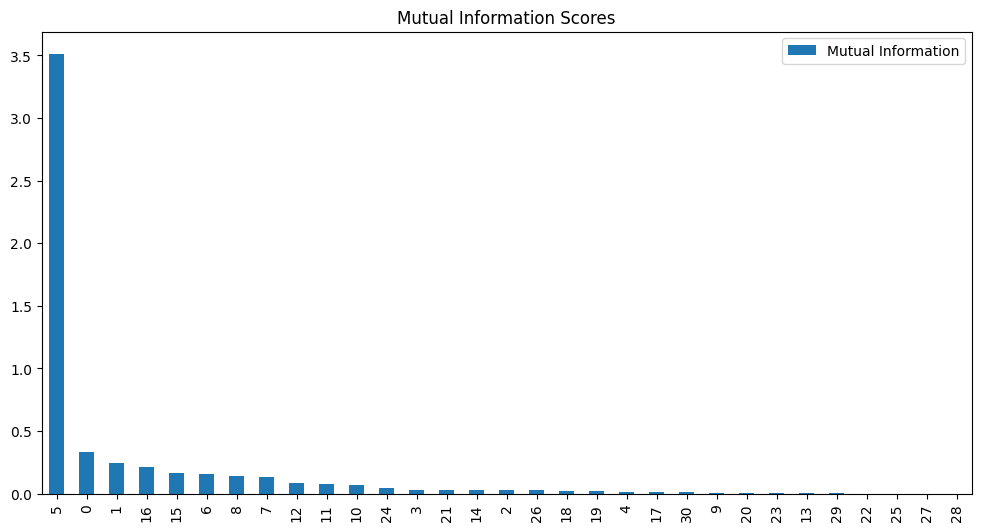

In [35]:
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

mutual_data = merged_data.copy()

for col in mutual_data.select_dtypes(include=['object']).columns:
    mutual_data[col] = pd.Categorical(mutual_data[col]).codes

target = mutual_data['Units_Sold']
features = mutual_data.drop(columns=['Units_Sold', 'Product_ID', 'Store_ID', 'Supplier_ID'])
mi_scores = mutual_info_regression(features, target)
mi_scores = mi_scores = pd.DataFrame({
    'Feature': features.columns,
    'Mutual Information': mi_scores
})
mi_scores = mi_scores.sort_values(by='Mutual Information', ascending=False)
print(mi_scores)

mi_scores.plot(kind='bar', figsize=(12, 6))
plt.title('Mutual Information Scores')
plt.show()

In [36]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Compute mutual information scores
mi_score = mutual_info_regression(x, target, random_state=42)

# Convert to DataFrame for readability
feature_importance = pd.DataFrame({
    'feature': x.columns,
    'mi_score': mi_score
}).sort_values(by='mi_score', ascending=False)

# Display full ranked list
print(feature_importance)

# Get top 10 features as list
top_10_features = feature_importance.head(10)['feature'].tolist()
print("\nTop 10 Important Features:", top_10_features)


                                    feature  mi_score
5                             Wastage_Units  3.514342
0                              Product_Name  0.329312
1                           Shelf_Life_Days  0.244362
16                    Product_Category_Meat  0.205752
15                   Product_Category_Dairy  0.165477
6                                     Price  0.159029
8                     Cold_Storage_Capacity  0.138457
7                                Store_Size  0.134288
12                                 Rainfall  0.079812
11                          Avg_Temperature  0.075904
10                          Supply_Capacity  0.072797
24      Supplier_Name_GreenValley Suppliers  0.039672
21                        Region_South West  0.034699
14               Product_Category_Beverages  0.031799
3                           Marketing_Spend  0.030939
2                               Week_Number  0.027530
26     Supplier_Name_OrganicChoice Partners  0.021713
30   Supplier_Name_TrustedSo

In [37]:
# Compute mutual information
mi_score = mutual_info_regression(features, target, random_state=42)

# Convert to DataFrame for readability
mi_score_df = pd.DataFrame({
    'features': features.columns,
    'MI Score': mi_score
}).sort_values(by='MI Score', ascending=False)

# Get top 10 feature names as list
top_10_features = mi_score_df.head(10)['features'].tolist()

print(top_10_features)


['Wastage_Units', 'Product_Name', 'Shelf_Life_Days', 'Product_Category_Meat', 'Product_Category_Dairy', 'Price', 'Cold_Storage_Capacity', 'Store_Size', 'Rainfall', 'Avg_Temperature']


In [39]:
training_features = mi_score_df.head(10)['features'].tolist()

In [42]:
training_features

['Wastage_Units',
 'Product_Name',
 'Shelf_Life_Days',
 'Product_Category_Meat',
 'Product_Category_Dairy',
 'Price',
 'Cold_Storage_Capacity',
 'Store_Size',
 'Rainfall',
 'Avg_Temperature']

In [43]:
training_15_features = mi_score_df.head(15)['features'].tolist()

In [44]:
training_15_features

['Wastage_Units',
 'Product_Name',
 'Shelf_Life_Days',
 'Product_Category_Meat',
 'Product_Category_Dairy',
 'Price',
 'Cold_Storage_Capacity',
 'Store_Size',
 'Rainfall',
 'Avg_Temperature',
 'Supply_Capacity',
 'Supplier_Name_GreenValley Suppliers',
 'Region_South West',
 'Product_Category_Beverages',
 'Marketing_Spend']

# Building the Model

In [45]:
training_features

['Wastage_Units',
 'Product_Name',
 'Shelf_Life_Days',
 'Product_Category_Meat',
 'Product_Category_Dairy',
 'Price',
 'Cold_Storage_Capacity',
 'Store_Size',
 'Rainfall',
 'Avg_Temperature']

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,mean_absolute_percentage_error


def train_linear_model(data):
    # Prepare data
    X = data[training_features]
    y = data['Units_Sold']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Initialize and train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    print("Linear Regression Model Performance:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"Mean Absolute Percentage Error: {mape:.2f}")
    
    return model

In [53]:
model = train_linear_model(merged_data)


Linear Regression Model Performance:
Mean Squared Error: 248645.37
R^2 Score: 0.82
Mean Absolute Error: 331.34
Root Mean Squared Error: 498.64
Mean Absolute Percentage Error: 0.23


In [55]:
from sklearn.tree import DecisionTreeRegressor

def train_decision_tree_model(data):
    # Prepare data
    X = data[training_features]
    y = data['Units_Sold']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Initialize and train model
    model = DecisionTreeRegressor()
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    print("Decision Tree Regressor Model Performance:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"Mean Absolute Percentage Error: {mape:.2f}")
    
    return model

In [56]:
model = train_decision_tree_model(merged_data)

Decision Tree Regressor Model Performance:
Mean Squared Error: 2503.30
R^2 Score: 1.00
Mean Absolute Error: 10.51
Root Mean Squared Error: 50.03
Mean Absolute Percentage Error: 0.01


In [58]:
from sklearn.ensemble import RandomForestRegressor

def train_rf_model(data):
    # Prepare data
    X = data[training_features]
    y = data['Units_Sold']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Initialize and train model
    model = RandomForestRegressor( n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    print("Random Forest Regressor Model Performance:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"Mean Absolute Percentage Error: {mape:.2f}")
    
    return model

In [59]:
model = train_rf_model(merged_data)

Random Forest Regressor Model Performance:
Mean Squared Error: 892.59
R^2 Score: 1.00
Mean Absolute Error: 8.40
Root Mean Squared Error: 29.88
Mean Absolute Percentage Error: 0.01


In [64]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split


def train_xgboost_model(data):
    import xgboost as xgb
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

    # Prepare data
    X = data[training_features]
    y = data['Units_Sold']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Initialize and train model
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    print("XGBoost Regressor Model Performance:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"Mean Absolute Percentage Error: {mape}")
    
    return model

In [65]:
model = train_xgboost_model(merged_data)

XGBoost Regressor Model Performance:
Mean Squared Error: 5489.19
R^2 Score: 0.9960638882102298
Mean Absolute Error: 21.85
Root Mean Squared Error: 74.09
Mean Absolute Percentage Error: 0.012550458576489716


In [70]:

def train_xgboost_model(data, training_features):
    # Prepare data
    X = data[training_features]
    y = data['Units_Sold']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Initialize and train model
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective='reg:squarederror'
    )
    model.fit(X_train, y_train)
    
    # Make predictions on test set
    y_pred = model.predict(X_test)
    
    # Evaluate model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    print("TEST PERFORMANCE")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.4f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"Mean Absolute Percentage Error: {mape:.4f}")
    
    # Return everything for further evaluation
    return model, X_train, X_test, y_train, y_test


In [76]:
model = train_xgboost_model(data=merged_data, training_features=training_features)

TEST PERFORMANCE
Mean Squared Error: 5489.19
R^2 Score: 0.9961
Mean Absolute Error: 21.85
Root Mean Squared Error: 74.09
Mean Absolute Percentage Error: 0.0126


In [74]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Define base model
xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)


Fitting 3 folds for each of 108 candidates, totalling 324 fits


/home/asus/Predicting_Perishables-/venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/asus/Predicting_Perishables-/venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estima

/home/asus/Predicting_Perishables-/venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/asus/Predicting_Perishables-/venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.2s[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=1.0; total time=   0.3s

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estima

/home/asus/Predicting_Perishables-/venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.4s[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.4s

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estima

In [77]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [78]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("TEST PERFORMANCE AFTER TUNING")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Percentage Error: {mape*100:.2f}%")


TEST PERFORMANCE AFTER TUNING
R² Score: 0.9959
Mean Absolute Error: 16.27
Root Mean Squared Error: 75.28
Mean Absolute Percentage Error: 0.86%


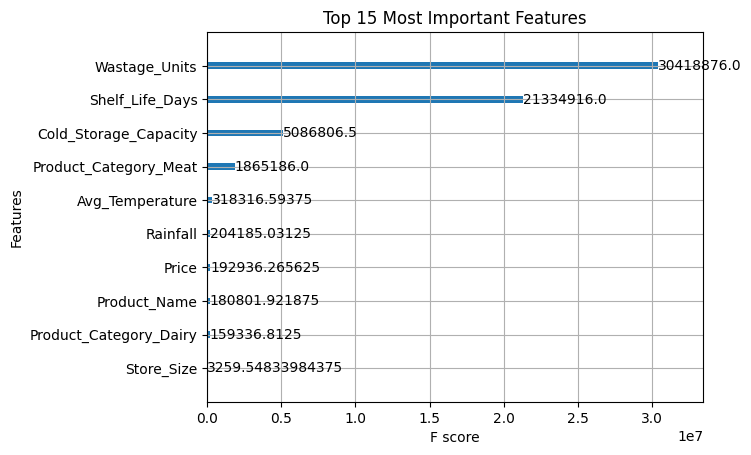

In [79]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Plot feature importance directly from your trained model
xgb.plot_importance(best_model, importance_type='gain', max_num_features=15)
plt.title("Top 15 Most Important Features")
plt.show()


In [81]:
import joblib

# Save the trained model
joblib.dump(best_model, "xgboost_model.pkl")



['xgboost_model.pkl']

In [82]:
import joblib

# training_features
joblib.dump(training_features, "xgboost_features.pkl")



['xgboost_features.pkl']

In [84]:
# encoders and metadata
encoding_artifacts = {
    "label_encoders": {col: LabelEncoder().fit(merged_data[col]) for col in high_cardinality},
    "low_cardinality_cols": low_cardinality,
    "high_cardinality_cols": high_cardinality
}

# Save using joblib
joblib.dump(encoding_artifacts, "encoding_artifacts.pkl")



['encoding_artifacts.pkl']

In [86]:
import json

#Save feature list
with open("xgboost_features.json", "w") as f:
    json.dump(training_features, f)

print(" Training feature names saved successfully as 'xgboost_features.json'")


 Training feature names saved successfully as 'xgboost_features.json'


In [87]:
training_features

['Wastage_Units',
 'Product_Name',
 'Shelf_Life_Days',
 'Product_Category_Meat',
 'Product_Category_Dairy',
 'Price',
 'Cold_Storage_Capacity',
 'Store_Size',
 'Rainfall',
 'Avg_Temperature']